In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
hiv_df = pd.read_csv('HIV data 2000-2023.csv', encoding="ISO-8859-1")
hiv_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000]
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000]
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000]
3,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2020,320 000 [280 000 - 370 000]
4,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2015,300 000 [260 000 - 350 000]


In [6]:
hiv_df = hiv_df[hiv_df['Value'].str.lower() != 'no data']
hiv_df['Value'] = hiv_df['Value'].replace({'<100 [<100 - <100]': 50, '<100 [<100 - <200]': 150, '<200 [<100 - <200]': 150,
                                            '<200 [<200 - <200]': 100, '<200 [<200 - <500]': 350, '<500 [<200 - <500]': 350,
                                            '<500 [<500 - <500]': 250, '<500 [<500 - <510]': 505, '<500 [<500 - <520]': 510,
                                            '<500 [<500 - <530]': 515, '<500 [<500 - <650]': 575, '<500 [<500 - <690]': 595,
                                            '<200 [<100 - <500]': 300, '<200 [<200 - <620]': 410})
hiv_df["HIV Estimate"] = hiv_df["Value"].astype(str).str.replace(" ", "").str.extract(r"(\d+)").astype(float)

In [8]:
country_totals = hiv_df.groupby("Location")["HIV Estimate"].sum().sort_values(ascending=False).reset_index()

total_sum = country_totals["HIV Estimate"].sum()
country_totals["Cumulative_%"] = country_totals["HIV Estimate"].cumsum() / total_sum * 100

top_75_countries = country_totals[country_totals["Cumulative_%"] <= 75]["Location"].to_list()

top_75_countries

['South Africa',
 'Mozambique',
 'Nigeria',
 'Kenya',
 'United Republic of Tanzania',
 'Zimbabwe',
 'Uganda',
 'Zambia',
 'Malawi',
 'Brazil',
 'Thailand',
 'Ethiopia',
 'Democratic Republic of the Congo',
 "Cote d'Ivoire"]

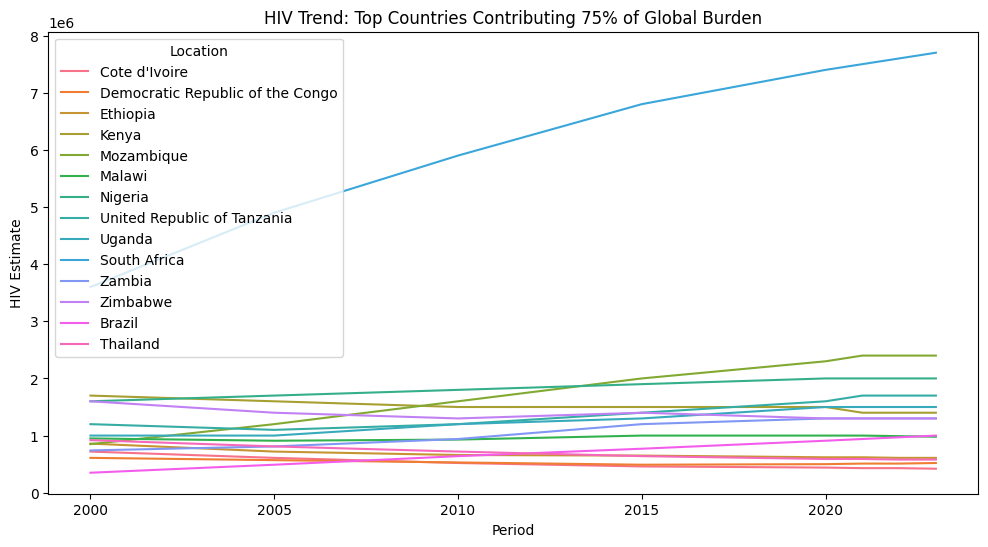

In [11]:
top_df = hiv_df[hiv_df["Location"].isin(top_75_countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=top_df, x="Period", y="HIV Estimate", hue="Location")
plt.title("HIV Trend: Top Countries Contributing 75% of Global Burden")
plt.ylabel("HIV Estimate")

plt.show()

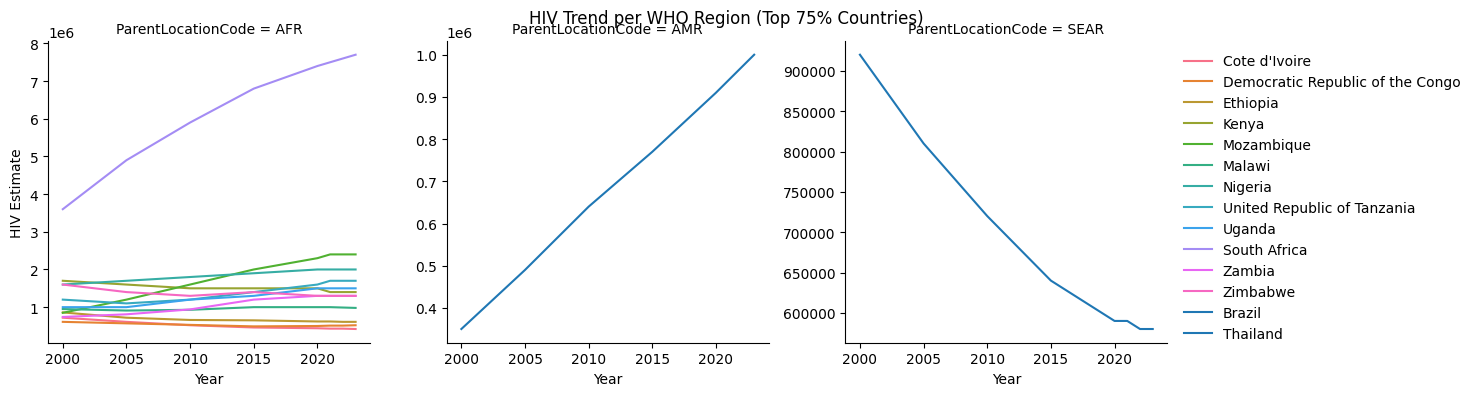

In [12]:
top_df = hiv_df[hiv_df["Location"].isin(top_75_countries)]

g = sns.FacetGrid(top_df, col="ParentLocationCode", col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.lineplot, x="Period", y="HIV Estimate", hue="Location")
g.add_legend()

g.set_axis_labels("Year", "HIV Estimate")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("HIV Trend per WHO Region (Top 75% Countries)")

plt.show()

In [13]:
top_df

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value,HIV Estimate
48,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2023,420 000 [370 000 - 480 000],420000.0
49,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2022,430 000 [380 000 - 490 000],430000.0
50,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2021,430 000 [390 000 - 490 000],430000.0
51,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2020,440 000 [390 000 - 490 000],440000.0
52,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2015,460 000 [420 000 - 510 000],460000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1323,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,SEAR,South-East Asia,Country,THA,Thailand,Year,2020,590 000 [530 000 - 680 000],590000.0
1324,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,SEAR,South-East Asia,Country,THA,Thailand,Year,2015,640 000 [580 000 - 730 000],640000.0
1325,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,SEAR,South-East Asia,Country,THA,Thailand,Year,2010,720 000 [630 000 - 790 000],720000.0
1326,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,SEAR,South-East Asia,Country,THA,Thailand,Year,2005,810 000 [720 000 - 910 000],810000.0


In [18]:
poverty_df = pd.read_excel("multidimensional_poverty.xlsx", sheet_name="data")

poverty_df.to_csv("multidimensional_poverty.csv", index=False)
poverty_df

,Region,Country code,Economy,Reporting year,Survey name,Survey year,Survey coverage,Welfare type,Survey comparability,Monetary (%),Educational attainment (%),Educational enrollment (%),Electricity (%),Sanitation (%),Drinking water (%),Multidimensional poverty headcount ratio (%)
0,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606
1,ECA,ALB,Albania,2012,HBS,2018,N,c,1,0.048107,0.19238,-,0.06025,6.579772,9.594966,0.293161
2,LAC,ARG,Argentina,2010,EPHC-S2,2021,U,i,3,0.894218,1.08532,0.731351,0,0.257453,0.364048,0.906573
3,ECA,ARM,Armenia,2010,ILCS,2021,N,c,1,0.523521,0,1.793004,0,0.397725,0.660082,0.523521
4,EAP,AUS,Australia,2010,SIH-LIS,2018,N,I,3,0.516880,1.71188,-,0,0,-,2.215770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,ECA,UZB,Uzbekistan,2022,HBS,2022,N,c,1,2.253092,0,-,0.12747,21.786885,10.693686,2.253092
106,EAP,VNM,Viet Nam,2010,VHLSS,2022,N,c,2,0.963795,3.384816,1.841407,0.079733,4.132901,1.968127,1.266184
107,EAP,VUT,Vanuatu,2010,NSDP,2019,N,c,0,9.963333,25.723079,13.404277,26.994166,42.970088,11.813611,19.892171
108,SSA,ZMB,Zambia,2010,LCMS-VIII,2022,N,c,4,64.341974,16.267821,23.39835,45.135146,53.505135,26.849246,66.506058


In [30]:
merged_df = pd.merge(hiv_df, poverty_df, left_on=["SpatialDimValueCode", "Period"], right_on=["Country code", "Reporting year"], how="inner")

In [39]:
merged_df.columns

Index(['IndicatorCode', 'Indicator', 'ValueType', 'ParentLocationCode',
       'ParentLocation', 'Location type', 'SpatialDimValueCode', 'Location',
       'Period type', 'Period', 'Value', 'HIV Estimate', 'Region',
       'Country code', 'Economy', 'Reporting year', 'Survey name',
       'Survey year', 'Survey coverage', 'Welfare type',
       'Survey comparability', 'Monetary', 'EducationAttainment',
       'EducationEnrollment', 'Electricity', 'Sanitation', 'WaterAccess',
       'PovertyRatio'],
      dtype='object')

In [41]:
merged_df = merged_df.rename(columns={
    "HIV Estimate": "HIVEstimate",
    "Educational attainment (%)": "EducationAttainment",
    "Educational enrollment (%)": "EducationEnrollment",
    "Electricity (%)": "Electricity",
    "Sanitation (%)": "Sanitation",
    "Drinking water (%)": "WaterAccess",
    "Multidimensional poverty headcount ratio (%)": "PovertyRatio"
})

In [54]:
selected_columns = ['IndicatorCode', 'Indicator', 'ValueType', 'ParentLocationCode',
                    'ParentLocation', 'Location type', 'SpatialDimValueCode', 'Location',
                    'Period type', 'Period', 'HIVEstimate', 'Monetary', 'EducationAttainment', 'EducationEnrollment', 
                    'Electricity', 'Sanitation', 'WaterAccess', 'PovertyRatio']

filtered_df = merged_df[selected_columns].dropna()
import statsmodels.formula.api as smf

model = smf.mixedlm("HIVEstimate ~ Monetary + EducationAttainment + EducationEnrollment + "
                    "Electricity + Sanitation + WaterAccess + PovertyRatio", 
                    filtered_df,
                    groups=filtered_df["SpatialDimValueCode"])  # Grouping by SpatialDimValueCode
result = model.fit()

result.summary()

c:\Users\Masini\anaconda3\envs\myenv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Mixed Linear Model Regression Results
===============================================================================
Model:                  MixedLM       Dependent Variable:       HIVEstimate    
No. Observations:       32            Method:                   REML           
No. Groups:             32            Scale:                    8864055679.3025
Min. group size:        1             Log-Likelihood:           -344.1958      
Max. group size:        1             Converged:                Yes            
Mean group size:        1.0                                                    
-------------------------------------------------------------------------------
                        Coef.       Std.Err.   z    P>|z|    [0.025     0.975] 
-------------------------------------------------------------------------------
Intercept               -26944.550 38055.271 -0.708 0.479 -101531.510 47642.410
Monetary                 15901.927  7312.197  2.175 0.030    1570.285 30233.569
EducationAttainment       8916.419  3404.301  2.619 0.009    2244.111 15588.727
EducationEnrollment     -16150.572  4247.261 -3.803 0.000  -24475.050 -7826.093
Electricity             -10804.327  4828.039 -2.238 0.025  -20267.110 -1341.545
Sanitation               -4289.915  2547.880 -1.684 0.092   -9283.668   703.838
WaterAccess              23605.586  4507.097  5.237 0.000   14771.837 32439.334
PovertyRatio              4899.869  6872.649  0.713 0.476   -8570.276 18370.014
Group Var           8864055679.302                                             
===============================================================================

"""

In [46]:
cols = ["Monetary", "EducationAttainment", "EducationEnrollment", "Electricity", "Sanitation", "WaterAccess", "PovertyRatio"]
merged_df[cols] = merged_df[cols].replace('-', np.nan)
merged_df[cols] = merged_df[cols].apply(pd.to_numeric)

print(merged_df[cols].corr())


                     Monetary  EducationAttainment  EducationEnrollment  \
Monetary             1.000000             0.589785             0.367196   
EducationAttainment  0.589785             1.000000             0.647821   
EducationEnrollment  0.367196             0.647821             1.000000   
Electricity          0.927016             0.752665             0.417079   
Sanitation           0.679338             0.804190             0.729192   
WaterAccess          0.664273             0.493708             0.571388   
PovertyRatio         0.944963             0.778609             0.596636   

                     Electricity  Sanitation  WaterAccess  PovertyRatio  
Monetary                0.927016    0.679338     0.664273      0.944963  
EducationAttainment     0.752665    0.804190     0.493708      0.778609  
EducationEnrollment     0.417079    0.729192     0.571388      0.596636  
Electricity             1.000000    0.774053     0.589395      0.950466  
Sanitation              0.774

C:\Users\Masini\AppData\Local\Temp\ipykernel_11832\1786150152.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df[cols] = merged_df[cols].replace('-', np.nan)
